# v3qc — Truth-vs-estimated per-record AF on 8 SEEDMIX replicates (Chr1 SNPs)

**Created 2026-05-16.** v3qc analog of `af_truth_vs_estimate_8reps.ipynb`.

Compares:
- recipe truth (uniform 1/231 pool → cn_var projection)
- cactus_em v3qc (regular)
- cactus_em v3qc + filt2 (singleton-k-mer filter)
- hapFIRE
- panel-level v3qc-vs-GN diff (no EM)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.sparse import load_npz

ROOT = Path('/carnegie/nobackup/scratch/tbellagio/hapfire_sv')
CEM_DIR       = ROOT / 'scratch/seedmix_v3qc_dedup'
CEM_FILT2_DIR = ROOT / 'scratch/seedmix_v3qc_filt2_dedup'
HF_DIR = Path('/carnegie/nobackup/scratch/xwu/GrENE_net/hapFIRE_frequencies/seed_mix')
CN_VAR = ROOT / 'poolfreq/data/cn_var_231_v3qc.cn_var.npz'
CN_VAR_META = ROOT / 'poolfreq/data/cn_var_231_v3qc.meta.npz'

meta = np.load(CN_VAR_META, allow_pickle=True)
rec_chrom = np.asarray(meta['chrom']).astype(str)
rec_pos   = np.asarray(meta['pos']).astype(np.int64)
rec_rlen  = np.asarray(meta['ref_len']).astype(np.int32)
rec_alen  = np.asarray(meta['alt_len']).astype(np.int32)

chr1_snp_mask = (rec_chrom == 'Chr1') & (rec_rlen == 1) & (rec_alen == 1)
chr1_snp_idx = np.where(chr1_snp_mask)[0]
chr1_snp_pos = rec_pos[chr1_snp_idx]
print(f'Chr1 SNP records in cn_var_v3qc: {len(chr1_snp_idx):,}')

cn_var = load_npz(CN_VAR)
F = cn_var.shape[0]
TRUTH_H = np.full(F, 1.0/F, dtype=np.float32)
cv_chr1_snps = cn_var[:, chr1_snp_idx].toarray().astype(np.float32)
truth_af = TRUTH_H @ cv_chr1_snps
print(f'recipe-projected truth_af: min={truth_af.min():.4f}, max={truth_af.max():.4f}, mean={truth_af.mean():.4f}')

Chr1 SNP records in cn_var_v3qc: 790,956


recipe-projected truth_af: min=0.0043, max=1.0000, mean=0.0699


In [2]:
def load_cem_chr1_snp_af(d, s):
    df = pd.read_csv(d / f'SEEDMIX_S{s}.tsv', sep='\t')
    return df['alt_freq'].to_numpy()[chr1_snp_idx]

def load_hapfire_chr1_af(s):
    df = pd.read_csv(HF_DIR / f's{s}_snp_frequency.txt', sep='\t',
                     header=None, names=['chrom','pos','af'])
    df = df[df['chrom'].astype(str) == '1']
    return dict(zip(df['pos'].astype(np.int64), df['af'].astype(np.float32)))

cem_af   = {s: load_cem_chr1_snp_af(CEM_DIR, s) for s in range(1, 9)}
filt2_af = {s: load_cem_chr1_snp_af(CEM_FILT2_DIR, s) for s in range(1, 9)}
hf_af_d  = {s: load_hapfire_chr1_af(s) for s in range(1, 9)}

hf_af_aligned = {}
for s in range(1, 9):
    d = hf_af_d[s]
    hf_af_aligned[s] = np.array([d.get(p, np.nan) for p in chr1_snp_pos], dtype=np.float32)
print('loaded all 8 reps x 3 methods')

loaded all 8 reps x 3 methods


## Per-replicate quadruplet of scatters

Each row = one replicate; 4 columns:
1. cactus_em-v3qc vs recipe truth
2. cactus_em-v3qc-filt2 vs recipe truth
3. cactus_em-v3qc vs hapFIRE
4. cactus_em-v3qc-filt2 vs hapFIRE

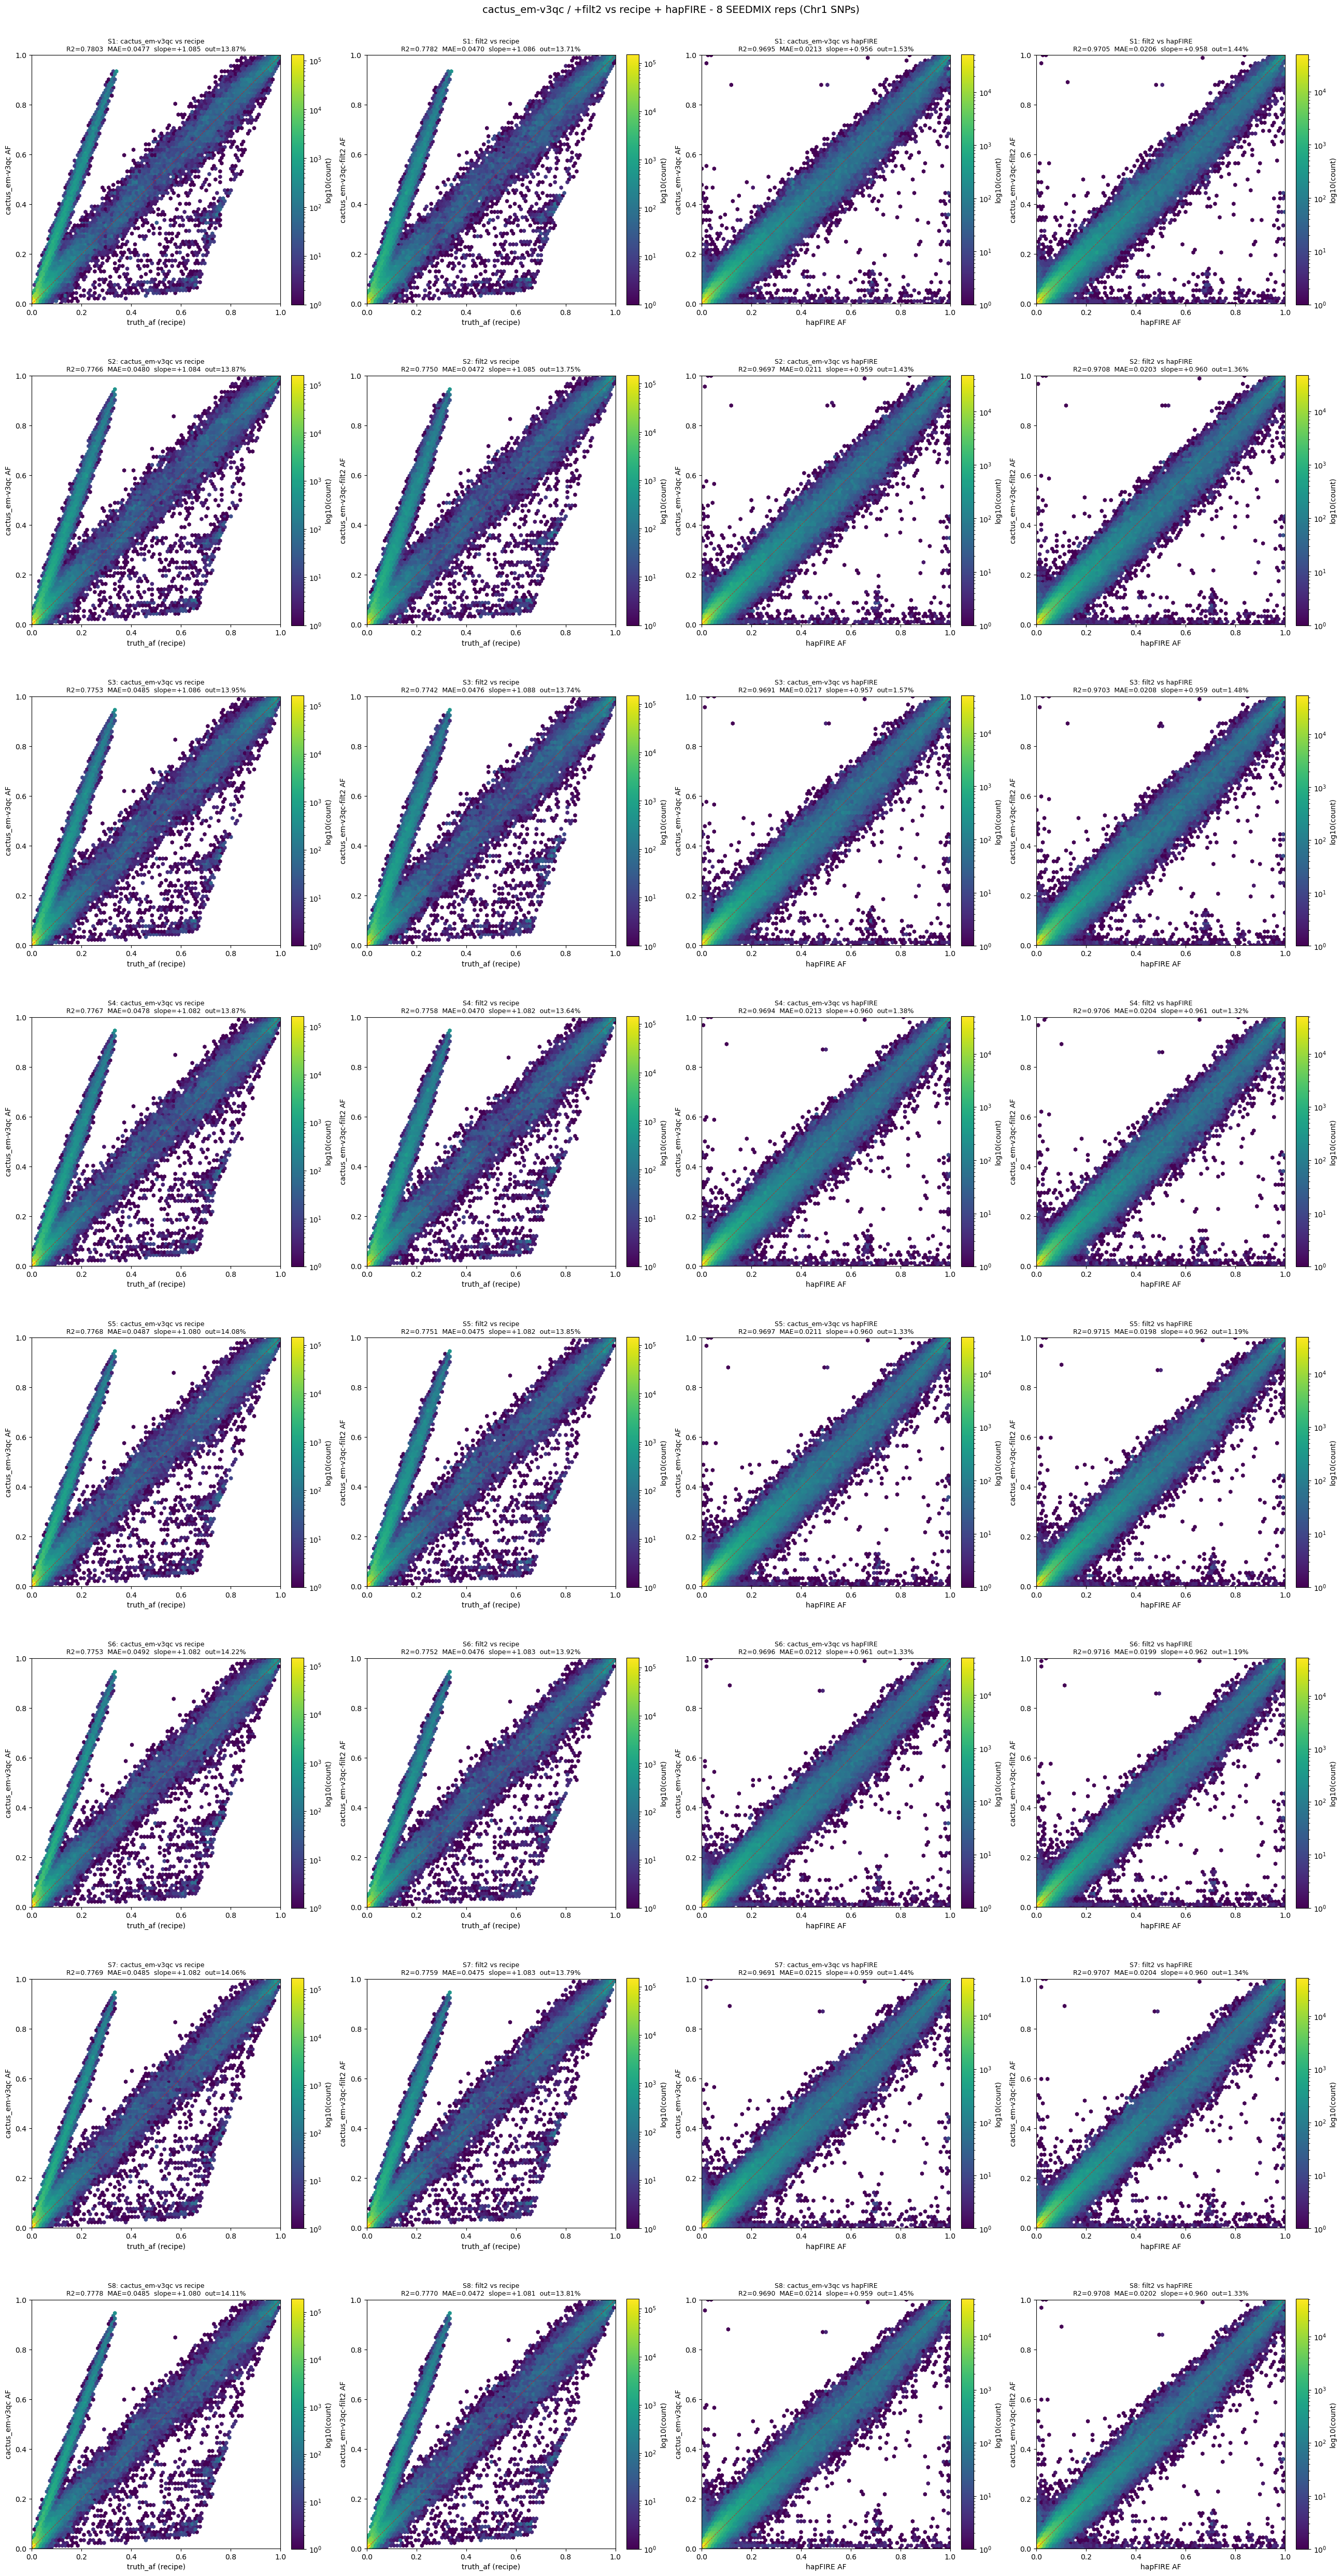

In [3]:
def metrics(x, y):
    finite = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x <= 1) & (y >= 0) & (y <= 1)
    if finite.sum() < 5: return None
    xv = x[finite]; yv = y[finite]
    return dict(
        n=int(finite.sum()),
        r2=float(np.corrcoef(xv, yv)[0,1]**2),
        mae=float(np.mean(np.abs(yv - xv))),
        slope=float(np.polyfit(xv, yv, 1)[0]),
        out=float(np.mean(np.abs(yv - xv) > 0.1)),
    )

def hexbin(ax, x, y, xlabel, ylabel, title):
    finite = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x <= 1) & (y >= 0) & (y <= 1)
    if finite.sum() < 5:
        ax.text(0.5, 0.5, 'no overlap', ha='center', va='center')
        return
    hb = ax.hexbin(x[finite], y[finite], gridsize=80, cmap='viridis', norm=LogNorm(), mincnt=1)
    ax.plot([0,1],[0,1],'r--', lw=0.7, alpha=0.7)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    m = metrics(x, y)
    ax.set_title(f'{title}\nR2={m["r2"]:.4f}  MAE={m["mae"]:.4f}  slope={m["slope"]:+.3f}  out={100*m["out"]:.2f}%', fontsize=9)
    plt.colorbar(hb, ax=ax, label='log10(count)', fraction=0.046, pad=0.04)

fig, axes = plt.subplots(8, 4, figsize=(26, 50))
for s in range(1, 9):
    row = s - 1
    cem = cem_af[s]
    f2  = filt2_af[s]
    hf  = hf_af_aligned[s]
    hexbin(axes[row, 0], truth_af, cem, 'truth_af (recipe)', 'cactus_em-v3qc AF', f'S{s}: cactus_em-v3qc vs recipe')
    hexbin(axes[row, 1], truth_af, f2,  'truth_af (recipe)', 'cactus_em-v3qc-filt2 AF', f'S{s}: filt2 vs recipe')
    hexbin(axes[row, 2], hf, cem, 'hapFIRE AF', 'cactus_em-v3qc AF', f'S{s}: cactus_em-v3qc vs hapFIRE')
    hexbin(axes[row, 3], hf, f2,  'hapFIRE AF', 'cactus_em-v3qc-filt2 AF', f'S{s}: filt2 vs hapFIRE')

fig.suptitle('cactus_em-v3qc / +filt2 vs recipe + hapFIRE - 8 SEEDMIX reps (Chr1 SNPs)', y=0.998, fontsize=14)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_8REPS_V3QC.png', dpi=130, bbox_inches='tight')
plt.show()

## Cross-replicate summary table

In [4]:
rows = []
for s in range(1, 9):
    cem = cem_af[s]; f2 = filt2_af[s]; hf = hf_af_aligned[s]
    for comp_label, comp in [('recipe', truth_af), ('hapFIRE', hf)]:
        for method_label, est in [('cactus_em-v3qc', cem), ('cactus_em-v3qc-filt2', f2)]:
            m = metrics(comp, est)
            if m is None: continue
            rows.append(dict(replicate=s, comparator=comp_label, method=method_label,
                             n=m['n'], r2=m['r2'], mae=m['mae'],
                             slope=m['slope'], out_pct=100*m['out']))
df = pd.DataFrame(rows)
print(df.to_string(index=False, float_format='%.4f'))
df.to_csv('AF_TRUTH_VS_ESTIMATE_8REPS_V3QC.tsv', sep='\t', index=False)

 replicate comparator               method      n     r2    mae  slope  out_pct
         1     recipe       cactus_em-v3qc 790956 0.7803 0.0477 1.0847  13.8743
         1     recipe cactus_em-v3qc-filt2 790956 0.7782 0.0470 1.0861  13.7072
         1    hapFIRE       cactus_em-v3qc 426551 0.9695 0.0213 0.9564   1.5314
         1    hapFIRE cactus_em-v3qc-filt2 426551 0.9705 0.0206 0.9581   1.4423
         2     recipe       cactus_em-v3qc 790956 0.7766 0.0480 1.0840  13.8747
         2     recipe cactus_em-v3qc-filt2 790956 0.7750 0.0472 1.0853  13.7511
         2    hapFIRE       cactus_em-v3qc 426551 0.9697 0.0211 0.9588   1.4289
         2    hapFIRE cactus_em-v3qc-filt2 426551 0.9708 0.0203 0.9601   1.3579
         3     recipe       cactus_em-v3qc 790956 0.7753 0.0485 1.0865  13.9468
         3     recipe cactus_em-v3qc-filt2 790956 0.7742 0.0476 1.0880  13.7359
         3    hapFIRE       cactus_em-v3qc 426551 0.9691 0.0217 0.9574   1.5660
         3    hapFIRE cactus_em-v3qc-fil

## Panel-level v3qc-vs-GN diff (no EM)

Pure panel-level alignment: v3qc carrier-rate AF vs GrENE-Net 1001G short-read carrier-rate AF on matched Chr1 SNPs.

Loaded 424,979 matched-SNP per-record AF diffs.


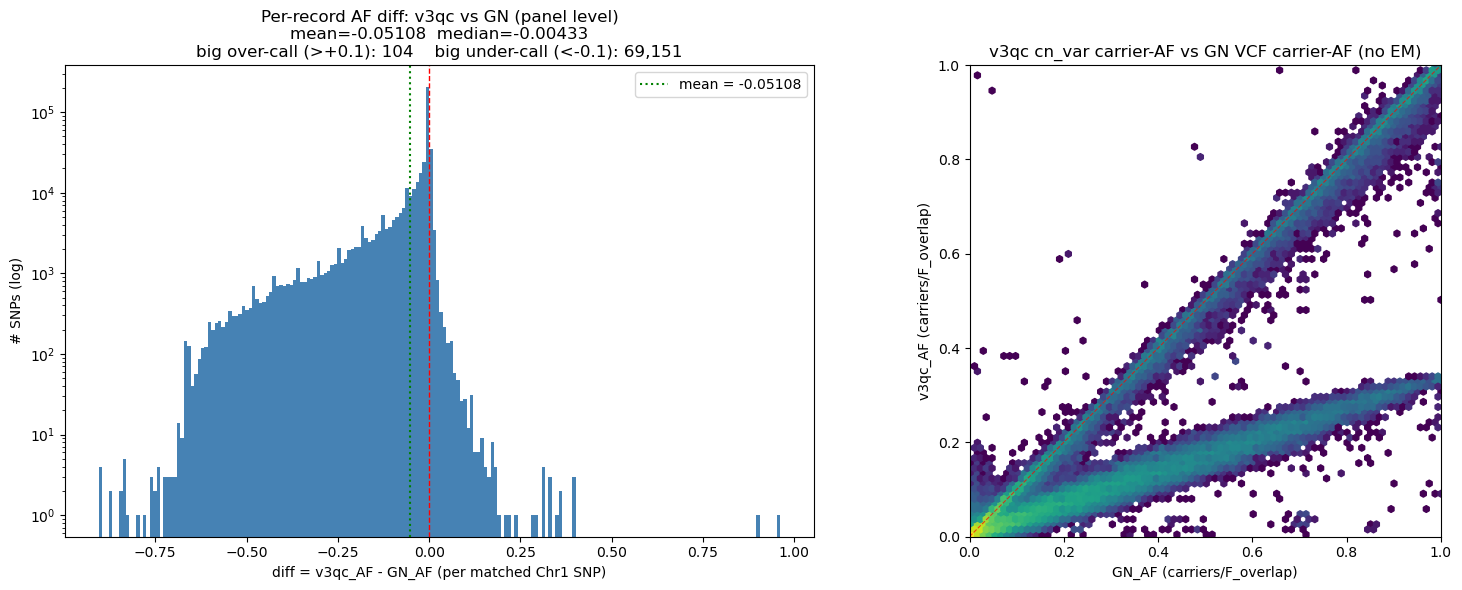

In [5]:
path = ROOT / 'scratch/v3qc_vs_gn_per_record_af.npz'
if path.exists():
    z = np.load(path)
    v3qc_af_panel = z['v3qc_af']
    gn_af_panel   = z['gn_af']
    diff_panel    = z['diff']
    print(f'Loaded {len(diff_panel):,} matched-SNP per-record AF diffs.')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].hist(diff_panel, bins=200, color='steelblue', edgecolor='none')
    axes[0].axvline(0, color='red', linestyle='--', lw=1)
    axes[0].axvline(diff_panel.mean(), color='green', linestyle=':', lw=1.5,
                    label=f'mean = {diff_panel.mean():+.5f}')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('diff = v3qc_AF - GN_AF (per matched Chr1 SNP)')
    axes[0].set_ylabel('# SNPs (log)')
    axes[0].set_title(f'Per-record AF diff: v3qc vs GN (panel level)\n'
                       f'mean={diff_panel.mean():+.5f}  median={np.median(diff_panel):+.5f}\n'
                       f'big over-call (>+0.1): {(diff_panel>0.1).sum():,}    '
                       f'big under-call (<-0.1): {(diff_panel<-0.1).sum():,}')
    axes[0].legend()

    axes[1].hexbin(gn_af_panel, v3qc_af_panel, gridsize=80, cmap='viridis', norm=LogNorm(), mincnt=1)
    axes[1].plot([0,1],[0,1],'r--', lw=0.8, alpha=0.7)
    axes[1].set_xlim(0,1); axes[1].set_ylim(0,1); axes[1].set_aspect('equal')
    axes[1].set_xlabel('GN_AF (carriers/F_overlap)')
    axes[1].set_ylabel('v3qc_AF (carriers/F_overlap)')
    axes[1].set_title('v3qc cn_var carrier-AF vs GN VCF carrier-AF (no EM)')
    plt.tight_layout()
    plt.savefig('plots/V3QC_VS_GN_PANEL_DIFF.png', dpi=140, bbox_inches='tight')
    plt.show()
else:
    print(f'{path} not found yet - wait for build_v3qc_refalt_and_diff.sh (job 62868) to finish.')